In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
import pandas as pd 
import seaborn as sns

# import nn PCA model from nuclear-norm-pca
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/nuclear-norm-pca')
import kuckle_model
from kuckle_model import *

### Settings and Load data

In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix')
import betabinomo_mix_singlecells as bbmix
import cell_state_asign_consistency as cellassign

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
metadata = pd.read_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/muscle_metadata.csv", sep="\t")
metadata.head()

,organ_tissue,free_annotation,cell_type,compartment
0,Muscle,endothelial cell of vascular tree,endothelial cell of vascular tree,endothelial
1,Muscle,capillary endothelial cell,capillary endothelial cell,endothelial
2,Muscle,endothelial cell of lymphatic vessel,endothelial cell of lymphatic vessel,endothelial
3,Muscle,mesenchymal stem cell,mesenchymal stem cell,stromal
4,Muscle,endothelial cell of artery,endothelial cell of artery,endothelial


In [5]:
metadata.cell_type.unique()

array(['endothelial cell of vascular tree', 'capillary endothelial cell',
       'endothelial cell of lymphatic vessel', 'mesenchymal stem cell',
       'endothelial cell of artery', 'pericyte cell',
       'cd4-positive, alpha-beta t cell',
       'skeletal muscle satellite stem cell', 'macrophage',
       'cd8-positive, alpha-beta t cell', 't cell', 'smooth muscle cell',
       'tendon cell', 'fast muscle cell', 'slow muscle cell', 'mast cell',
       'erythrocyte', 'mesothelial cell', 'mature nk t cell'],
      dtype=object)

In [6]:
#input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/'
#input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/"
#input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes")

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

# merge cell_ids_conversion with metadata to add more cell type information
# cell_ids_conversion = cell_ids_conversion.merge(metadata, on="cell_type")

simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4
The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [7]:
## simple PCA with imputation of missing values 

# make matrix of junctions by cells and fill with juncratio values 
mat = np.zeros((len(final_data.cell_id_index.unique()), len(final_data.junction_id_index.unique())))
mat[final_data.cell_id_index, final_data.junction_id_index] = final_data.juncratio
mat[~(final_data.cell_id_index), ~(final_data.junction_id_index)] = np.nan

# imput nan values using mean of each row (does this make sense?)
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(mat)
mat_imputed = imp.transform(mat)

# run PCA on mat_imputed 
pca = PCA(n_components=10)
pca.fit(mat_imputed)
print(pca.explained_variance_ratio_)

pcs = pca.transform(mat_imputed)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

[0.05224695 0.01492946 0.01087324 0.00494729 0.00401896 0.00289631
 0.00269034 0.00191864 0.001824   0.00162256]


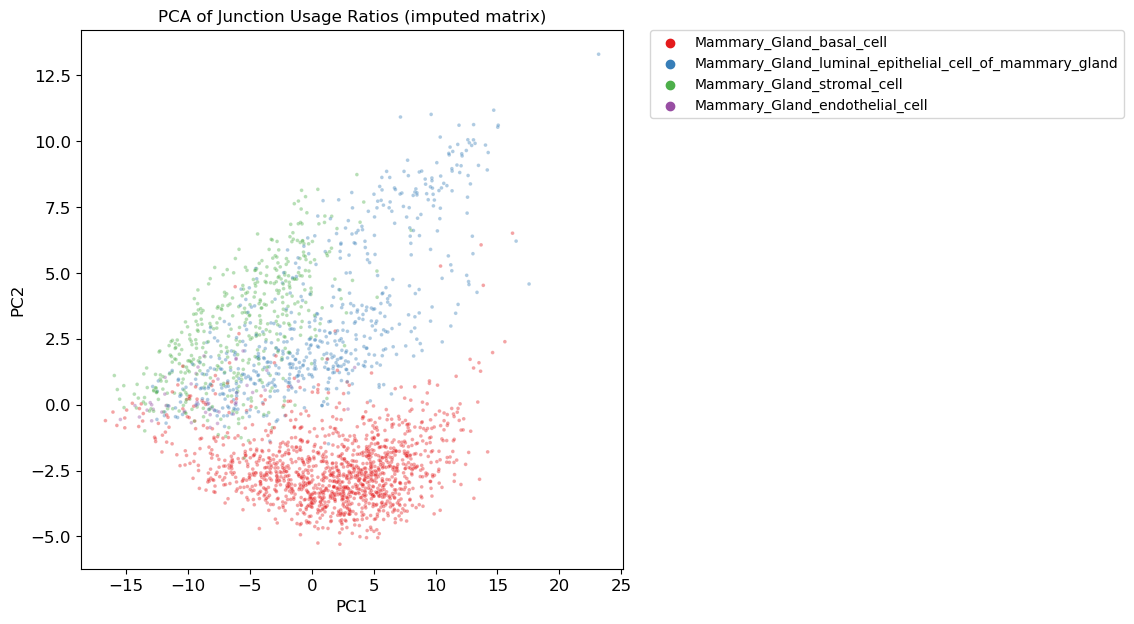

In [8]:
# plot first two PCs
plt.figure(figsize=(7, 7))
sns.scatterplot(data=pcs_df, x="PC1", y="PC2", hue=cell_types_pcs.values, s=7, alpha=0.4, palette="Set1")
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")
# increase font size of everything
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.show()

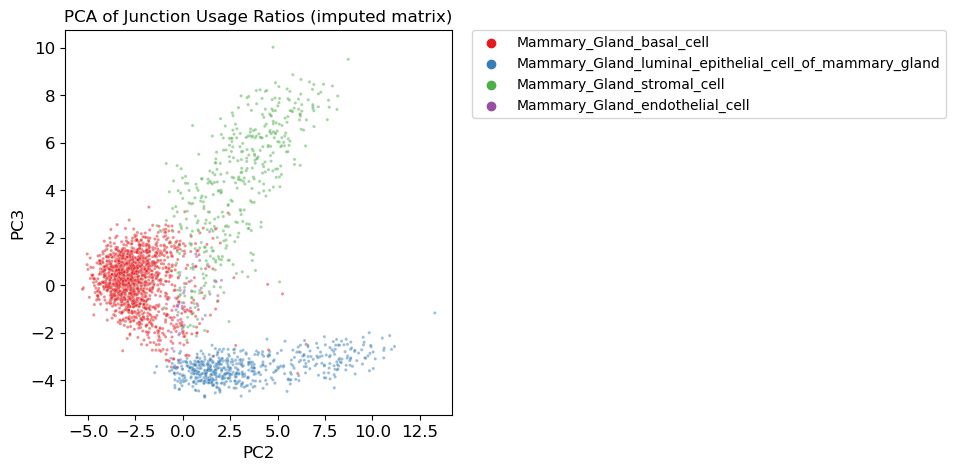

In [9]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=pcs_df, x="PC2", y="PC3", hue=cell_types_pcs.values, s=5, alpha=0.5, palette="Set1")
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")
# increase font size of everything
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("PC2", fontsize=12)
plt.ylabel("PC3", fontsize=12)
plt.show()

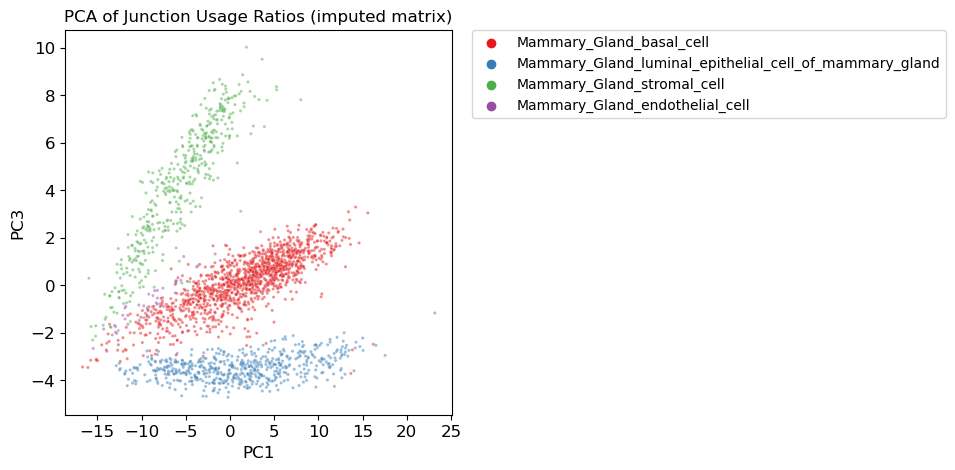

In [11]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=pcs_df, x="PC1", y="PC3", hue=cell_types_pcs.values, s=5, alpha=0.5, palette="Set1")
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")
# increase font size of everything
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC3", fontsize=12)
plt.show()

In [10]:
# let's use PCs to get silhouette scores via cell type labels 
# import silhouette_score
from sklearn.metrics import silhouette_score
print(silhouette_score(pcs, cell_ids_conversion.compartment.values)) # likely inflated by the imputation which may just reflect global gene expression trends?

# get Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score
print(davies_bouldin_score(pcs, cell_ids_conversion.compartment.values)) # lower is better

AttributeError: 'DataFrame' object has no attribute 'compartment'

### Filter junctions and set up Y and W (weight matrix of inverse variances of the PSI values)

also printing original indices of junctions we are keeping


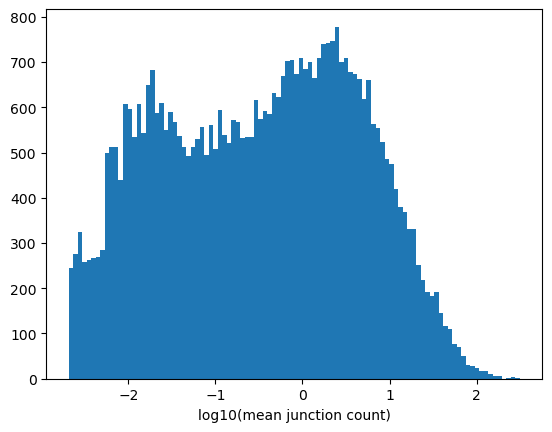

In [12]:
junc_counts_sub, cluster_counts_sub, junc_keep = filter_junctions(
    junc_counts, cluster_counts, plot = True)

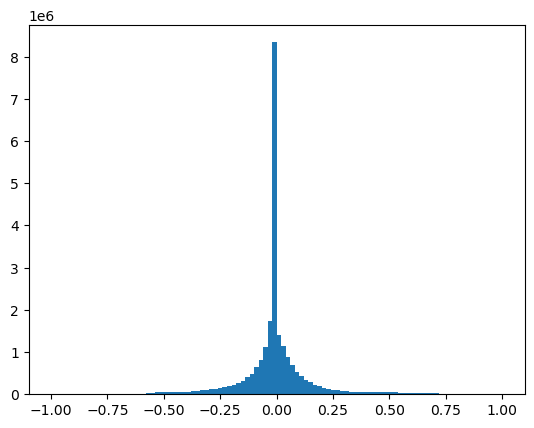

In [13]:
# set up data for nuc norm PCA
Y_data, w = make_Y(
    junc_counts_sub, cluster_counts_sub, float_type)

# np.mean(Y_data * Y_data) * psi.shape[0] * psi.shape[1]
Y = torch.tensor(Y_data, **float_type)
W = torch.tensor(w.data, **float_type)

_ = plt.hist(Y_data, 100) # centered so the distribution peaks at 0 and is in [-1,1]

### Split into training and test data 

In [16]:
Y_train, W_train, indices_train, Y_test, W_test, indices_test = train_test(
    Y_data, w, float_type)

### Run nuclear norm PCA constraint search 

In [17]:
rmseTol = 5e-5
its=10

rs, testErrors, trainErrors, nuc_norms, final_svd, step_times = constraint_search(
    indices_train, 
    Y_train, 
    W_train, 
    size = junc_counts_sub.shape,
    indices_test = indices_test, 
    Y_test = Y_test, 
    W_test = W_test, 
    rmseTol = rmseTol, 
    end = "\n",
    inner_verbose = True,
    power_iteration_controller = (30,1.),
    its = its,  
    **float_type)

CV	Bound	RMSE	TestRMSE
It	RMSE	Step	DeltaRMSE


OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB (GPU 0; 15.77 GiB total capacity; 3.26 GiB already allocated; 245.06 MiB free; 3.59 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

### Plot results 

In [ ]:
plt.plot(np.log10(rs), testErrors,"-o", label = "warmstart test") #rs = list of nuclear norm bounds used 
plt.plot(np.log10(rs), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(nuclear norm bound)")
plt.legend()

In [ ]:
plt.plot(final_svd.S)
plt.ylabel("Singular values of X") 
plt.xlabel("Singular value index")
# add title
plt.title("Singular values of X for nuclear norm PCA")
final_svd.S.sum()

In [ ]:
# solution is on the boundary up to about ~1e4, then is inside. 
plt.plot(np.log10(rs), np.log10(nuc_norms), "-o", label = "warmstart")
plt.xlabel("log10(Nuc norm bound)")
plt.ylabel("log10(Nuc norm obtained)")

In [ ]:
plt.plot(np.log10(nuc_norms), testErrors,"-o", label = "warmstart test")
plt.plot(np.log10(nuc_norms), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(obtained nuclear norm)")
plt.legend()

In [ ]:
r_best = rs[np.argmin(testErrors)]
Y,W,indices = to_torch(Y_data, w, **float_type)

### Re-run constraint_search with our best r_best

In [ ]:
rs, _, trainErrors_all, nuc_norms_all, final_svd_all, step_times = constraint_search(
    indices, 
    Y, 
    W, 
    size = junc_counts_sub.shape,
    rmseTol = rmseTol, 
    its = its,  
    max_r = r_best, 
    end = "\n",
    **float_type)


In [ ]:
print("The best nuclear norm bound:", r_best)

### Settings and Load data

In [ ]:
plt.plot(final_svd_all.S) # final_svd = orthonormer(U, V, phi) --> orthonormalization process on the singular vectors (stored in U and V) and singular values (phi) obtained from the nuc_norm_PCA
plt.xlabel("Singular value index")
plt.ylabel("Singular values of X")
plt.title("Singular values of X for nuclear norm PCA")

In [ ]:
# convert to df and rename columns to be PCA_1, PCA_2, etc.
PC_df = pd.DataFrame(final_svd_all.U)
PC_df.columns = ["PCA_" + str(i) for i in range(1, PC_df.shape[1] + 1)]
PC_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()
PC_df

In [ ]:
plt.figure(figsize=[7,7])
plt.grid()
sns.scatterplot(x = "PCA_1",y = "PCA_2", hue="cell_type", data= PC_df, edgecolor = 'none', alpha = 0.4, s=5)

In [ ]:
pve = final_svd_all.S**2
pve /= pve.sum()
pve = pve.cumsum(0) * 100
plt.plot(pve)
plt.ylabel("Cumulative percent variance explained")
# add xlabel
plt.xlabel("Singular value index")

In [ ]:
E = final_svd_all.U * final_svd_all.S  #in U, these are like the PCs..., S are the scaling factors that quantify the amount of variance captured by each corresponding singular vector in U.

In [ ]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

In [ ]:
# make a histogram of all the values in the torch tensor E
plt.hist(E.flatten(), 100)

In [ ]:
cluster = sns.clustermap(
    data=E,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'E'} 
    )
cluster.cax.set_ylabel('E', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [ ]:
# print cell type color legend seperately
cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

In [ ]:
# let's calculate silhouette score ussing assign_post
silhouette_score(E, cell_types)

In [ ]:
# compute Davies-Bouldin Index 
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(E, cell_types) # closer to zero indicates better partition 

In [ ]:
# run umap on E
import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(E)

In [ ]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.1,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

In [ ]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

In [ ]:
# Now run PCA on E 
pca = PCA(n_components=10)
pca.fit(E)
print(pca.explained_variance_ratio_)
pcs = pca.transform(E)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

In [ ]:
sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

## Evaluate effects of masking on nuclear norm pca E 
